# BiLSTM с Word2Vec эмбеддингами для классификации AG News

Ноутбук реализует классификатор BiLSTM с предобученными Word2Vec эмбеддингами для датасета AG News.

**Цель**: сравнить влияние предобученных эмбеддингов на качество BiLSTM модели.

**Датасет**: AG News (train/val 90/10 сплит фиксированным сидом; test отдельно)

**Модель**: Word2Vec Embedding(300) → BiLSTM(hidden=128, num_layers=1, bidirectional) → masked max-pooling по времени → Dropout(0.3) → Linear(4)


## Шаг 1: Импорты и настройка


In [1]:
!pip install pytorch-lightning

In [2]:
!pip install gensim

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
import numpy as np
from datasets import load_dataset
import re
from collections import Counter
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gensim.downloader as api

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
pl.seed_everything(42)

print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


INFO:lightning_fabric.utilities.seed:Seed set to 42


PyTorch version: 2.10.0+cu128
PyTorch Lightning version: 2.6.1
CUDA available: True


## Шаг 2: Загрузка и разбиение датасета

Используем тот же сплит что и в предыдущих ноутбуках для справедливого сравнения.


In [4]:
print("Loading AG News dataset...")
dataset = load_dataset("ag_news")

print(f"\nDataset structure:")
print(dataset)
print(f"\nTrain set size: {len(dataset['train'])}")
print(f"Test set size: {len(dataset['test'])}")

train_texts = dataset['train']['text']
train_labels = dataset['train']['label']
test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

Loading AG News dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Train set size: 120000
Test set size: 7600


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    list(train_texts), list(train_labels),
    test_size=0.1,
    random_state=42,
    stratify=list(train_labels)
)

print(f"\nAfter split:")
print(f"Train: {len(train_texts)}")
print(f"Val: {len(val_texts)}")
print(f"Test: {len(test_texts)}")

class_names = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f"\nClasses: {class_names}")



After split:
Train: 108000
Val: 12000
Test: 7600

Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


## Шаг 3: Токенизация и словарь

Строим словарь из обучающих данных. Используем ту же токенизацию для согласованности.


In [56]:
stop_words = {'a', 'an', 's', 'as', 'its', 'the', 'and', 'of', 'to', 'in', 'for', 'on', 'with',
                  'by', 'at', 'from', 'is', 'are', 'was', 'were', 'be', 'been',
                  'this', 'that', 'these', 'those', 'it', 'they', 'we', 'you',
                  'he', 'she', 'it', 'them', 'their', 'our', 'your'}

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'#[a-zA-Z0-9]+;', ' ', text)
    text = re.sub(r'\b\d+(?:\.\d+)?\b', '<NUM>', text)
    tokens = re.findall(r'\b\w+\b', text)
    tokens = [token for token in tokens if token not in stop_words]
    return tokens

In [57]:
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
PAD_IDX = 0
UNK_IDX = 1

print("Building vocabulary...")
word_counter = Counter()
for text in train_texts:
    tokens = simple_tokenize(text)
    word_counter.update(tokens)

print(f"Total unique words: {len(word_counter)}")
print(f"Words with freq >= 2: {sum(1 for count in word_counter.values() if count >= 2)}")

vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
vocab_size = 2

max_vocab_size = 30000
for word, count in word_counter.most_common():
    if count >= 2 and vocab_size < max_vocab_size:
        vocab[word] = vocab_size
        vocab_size += 1

print(f"\nVocabulary size: {len(vocab)}")
print(f"Top 10 words: {list(vocab.keys())[:10]}")

idx_to_word = {idx: word for word, idx in vocab.items()}


Building vocabulary...
Total unique words: 61291
Words with freq >= 2: 41475

Vocabulary size: 30000
Top 10 words: ['<pad>', '<unk>', 'NUM', 'new', 'said', 'reuters', 'has', 'ap', 'his', 'will']


## Шаг 4: Загрузка предобученных Word2Vec эмбеддингов

Загружаем предобученные Word2Vec эмбеддинги (например, word2vec-google-news-300) и создаём матрицу эмбеддингов для нашего словаря.


In [8]:
EMBEDDING_TYPE = "fasttext"# "w2v"
print(f"Loading {EMBEDDING_TYPE} embeddings...")

if EMBEDDING_TYPE == "w2v":
    emb_model = api.load("word2vec-google-news-300")
    embed_dim = emb_model.vector_size

elif EMBEDDING_TYPE == "fasttext":
    emb_model = api.load("fasttext-wiki-news-subwords-300")
    embed_dim = emb_model.vector_size

else:
    raise ValueError("Unknown embedding type")

Loading fasttext embeddings...


In [58]:
embed_dim = emb_model.vector_size

print(f"Word2Vec embedding dimension: {embed_dim}")
print(f"Vocabulary size in Word2Vec: {len(emb_model)}")

embedding_matrix = np.zeros((len(vocab), embed_dim))

found_words = 0
for word, idx in vocab.items():
    if word == PAD_TOKEN:
        continue
    elif word == UNK_TOKEN:
        embedding_matrix[idx] = np.random.normal(0, 0.1, embed_dim)
    elif word in emb_model:
        embedding_matrix[idx] = emb_model[word]
        found_words += 1
    else:
        embedding_matrix[idx] = np.random.normal(0, 0.1, embed_dim)

print(f"\nFound embeddings for {found_words} words out of {len(vocab)}")
print(f"Coverage: {found_words / len(vocab) * 100:.2f}%")

embedding_matrix = torch.FloatTensor(embedding_matrix)
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Word2Vec embedding dimension: 300
Vocabulary size in Word2Vec: 999999

Found embeddings for 25636 words out of 30000
Coverage: 85.45%
Embedding matrix shape: torch.Size([30000, 300])


## Шаг 5: Dataset класс с динамическим паддингом

Dataset класс возвращает последовательности без фиксированного паддинга. Паддинг до max в батче будет выполняться в collate_fn.


In [59]:
class AGNewsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=128):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        tokens = simple_tokenize(text)
        indices = [self.vocab.get(token, UNK_IDX) for token in tokens]

        if len(indices) > self.max_len:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = [len(text) for text in texts]
    max_len = max(lengths)

    padded_texts = []
    masks = []
    for text in texts:
        pad_length = max_len - len(text)
        padded = torch.cat([text, torch.full((pad_length,), PAD_IDX, dtype=torch.long)])
        mask = torch.cat([torch.ones(len(text), dtype=torch.bool), torch.zeros(pad_length, dtype=torch.bool)])
        padded_texts.append(padded)
        masks.append(mask)

    return torch.stack(padded_texts), torch.stack(masks), torch.stack(labels)

max_len = 64 # нет смысла брать высокие значения, т.к. 95% текстов короче 53 слов
train_dataset = AGNewsDataset(train_texts, train_labels, vocab, max_len=max_len)
val_dataset = AGNewsDataset(val_texts, val_labels, vocab, max_len=max_len)
test_dataset = AGNewsDataset(test_texts, test_labels, vocab, max_len=max_len)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

sample_text, sample_label = train_dataset[0]
print(f"\nSample:")
print(f"  Text length: {len(sample_text)}")
print(f"  Label: {sample_label.item()} ({class_names[sample_label.item()]})")


Train dataset size: 108000
Val dataset size: 12000
Test dataset size: 7600

Sample:
  Text length: 36
  Label: 1 (Sports)


## Шаг 6: Модель BiLSTM с предобученными эмбеддингами

Архитектура:
- Embedding слой: $E \in \mathbb{R}^{|V| \times d}$ где $d=300$ (Word2Vec), с `padding_idx=0`, инициализирован предобученными векторами
- BiLSTM: $\text{LSTM}(d, h=128, \text{bidirectional=True})$ → выход $h_t \in \mathbb{R}^{256}$ (forward + backward)
- Masked max-pooling: $\text{MaxPool}(\{h_t : \text{mask}_t = 1\})$ по временной оси
- Dropout(0.3) → Linear(256, 4)


In [65]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=300, hidden_dim=128, num_layers=1, num_classes=4, dropout=0.3, embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        if embedding_matrix is not None:
            self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze_embeddings, padding_idx=PAD_IDX)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)

        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, mask):
        x = self.embedding(x)
        x = self.dropout(x)
        lstm_out, _ = self.lstm(x)

        #mask_expanded = mask.unsqueeze(-1).expand_as(lstm_out)
        #lstm_out_masked = lstm_out.masked_fill(~mask_expanded, -1e9)
        #pooled, _ = torch.max(lstm_out_masked, dim=1)
        #x = self.dropout(pooled)

        mask = mask.unsqueeze(-1)  # [B, T, 1]
        attn_scores = self.attention(lstm_out)  # [B, T, 1]
        attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = torch.softmax(attn_scores, dim=1)  # [B, T, 1]
        context = (lstm_out * attn_weights).sum(dim=1)  # [B, 2H]

        x = self.dropout(context)
        x = self.fc(x)
        return x


## Шаг 7: Lightning модуль

PyTorch Lightning модуль с training/validation шагами, логированием train/val loss, val accuracy и val macro F1. Gradient clipping с clip_val=1.0.


In [75]:
class BiLSTMModule(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim=300, hidden_dim=128, num_layers=1, num_classes=4, dropout=0.3, lr=1e-3, embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        self.save_hyperparameters()
        self.model = BiLSTM(vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout, embedding_matrix, freeze_embeddings)
        self.lr = lr

        self.train_acc = MulticlassAccuracy(num_classes=num_classes)
        self.val_acc = MulticlassAccuracy(num_classes=num_classes)
        self.val_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')

        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

        self.train_loss_history = []
        self.val_loss_history = []
        self.val_acc_history = []
        self.val_f1_history = []

    def forward(self, x, mask):
        return self.model(x, mask)

    def training_step(self, batch, batch_idx):
        x, mask, y = batch
        logits = self(x, mask)
        loss = self.criterion(logits, y)

        self.train_acc(logits, y)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        self.log('train_acc', self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        self.train_loss_history.append(self.trainer.callback_metrics['train_loss_epoch'].item())

    def validation_step(self, batch, batch_idx):
        x, mask, y = batch
        logits = self(x, mask)
        loss = self.criterion(logits, y)

        self.val_acc(logits, y)
        self.val_f1(logits, y)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_acc', self.val_acc, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1', self.val_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        self.val_loss_history.append(self.trainer.callback_metrics['val_loss'].item())
        self.val_acc_history.append(self.trainer.callback_metrics['val_acc'].item())
        self.val_f1_history.append(self.trainer.callback_metrics['val_f1'].item())

    def configure_optimizers(self): # добавили scheduler
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
        #scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.estimated_stepping_batches)
        return {"optimizer": optimizer,"lr_scheduler": scheduler, "interval": "step", "frequency": 1,}
        #return torch.optim.Adam(self.parameters(), lr=self.lr)


## Шаг 8: DataLoaders

Создаём DataLoaders с batch_size=128 и collate_fn для динамического паддинга.


In [62]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, collate_fn=collate_fn, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=collate_fn, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
sample_batch = next(iter(train_loader))

x, mask, y = sample_batch
print(f"\nSample batch:")
print(f"  Text shape: {x.shape}")
print(f"  Mask shape: {mask.shape}")
print(f"  Labels shape: {y.shape}")

Train batches: 1688
Val batches: 188
Test batches: 119


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Sample batch:
  Text shape: torch.Size([64, 55])
  Mask shape: torch.Size([64, 55])
  Labels shape: torch.Size([64])


## Шаг 9: Обучение

Обучаем 3 эпохи с Adam оптимизатором (lr=1e-3), gradient_clip_val=1.0, seed=42. Эмбеддинги можно заморозить (freeze_embeddings=True) или дообучить (False). Отслеживаем время эпохи.


In [76]:
vocab_size = len(vocab)
freeze_embeddings = False

model = BiLSTMModule(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=128,
    num_layers=1,
    num_classes=4,
    dropout=0.5,
    lr=3e-3,
    embedding_matrix=embedding_matrix,
    freeze_embeddings=freeze_embeddings
)

checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    save_top_k=1,
    filename='best-model-{epoch:02d}-{val_acc:.4f}',
    auto_insert_metric_name=False
)

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='gpu',
    devices=1,
    enable_progress_bar=True,
    log_every_n_steps=50,
    gradient_clip_val=1.0
)

print("Starting training...")
print(f"Freeze embeddings: {freeze_embeddings}")
start_time = time.time()
trainer.fit(model, train_loader, val_loader)
total_time = time.time() - start_time

bilstm_w2v_epoch_time = total_time / 10

print(f"\nTraining completed in {total_time:.2f} seconds")
print(f"Average time per epoch: {bilstm_w2v_epoch_time:.2f} seconds")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting training...
Freeze embeddings: False


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/optimizer.py:378: Found unsupported keys in the optimizer configuration: {'interval', 'frequency'}


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ BiLSTM             │  9.4 M │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_f1    │ MulticlassF1Score  │      0 │ train │     0 │
│ 4 │ criterion │ CrossEntropyLoss   │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 9.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 9.4 M                                                                                                
Total estimated model params size (MB): 37                                                                         
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will 
create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller 
than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader 
running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.



Training completed in 572.95 seconds
Average time per epoch: 57.30 seconds


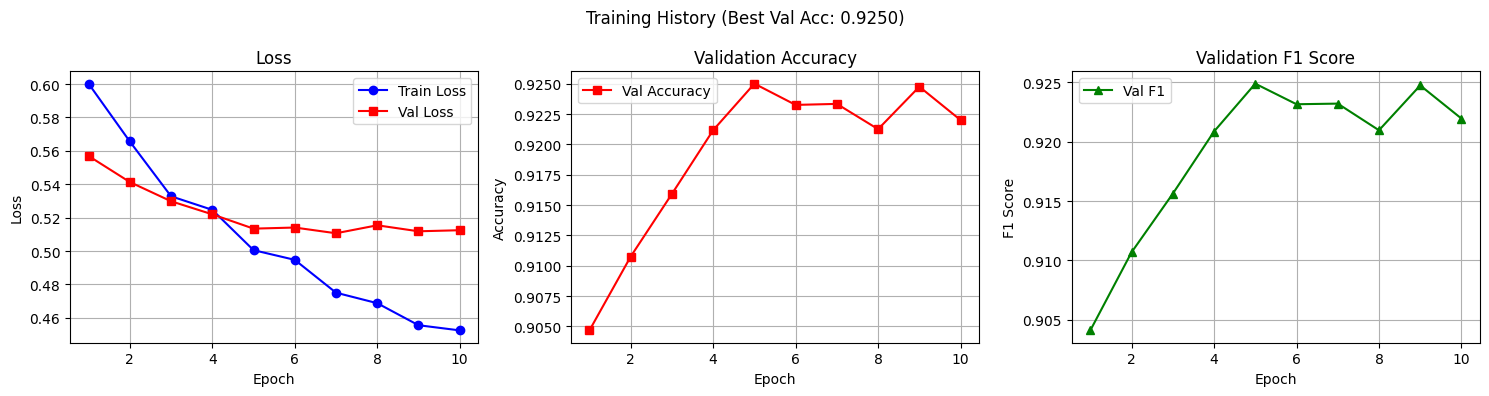

In [77]:
model.val_acc_history = model.val_acc_history[1:]
model.val_f1_history = model.val_f1_history[1:]
model.val_loss_history = model.val_loss_history[1:]

if len(model.val_acc_history) > 0:
    epochs = range(1, len(model.val_acc_history)+1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    if len(model.train_loss_history) > 0:
        axes[0].plot(epochs, model.train_loss_history, 'b-o', label='Train Loss')
    if len(model.val_loss_history) > 0:
        axes[0].plot(epochs, model.val_loss_history, 'r-s', label='Val Loss')

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, model.val_acc_history, 'r-s', label='Val Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(epochs, model.val_f1_history, 'g-^', label='Val F1')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].set_title('Validation F1 Score')
    axes[2].legend()
    axes[2].grid(True)

    plt.suptitle(f'Training History (Best Val Acc: {max(model.val_acc_history):.4f})')
    plt.tight_layout()
    plt.show()
else:
    print("No history available, showing final values only")
    print(f"Best Val Acc: {checkpoint_callback.best_model_score:.4f}")

## Шаг 10: Оценка на тесте

Оцениваем на test наборе: accuracy и macro F1 score.


In [78]:
test_acc = MulticlassAccuracy(num_classes=4)
test_f1 = MulticlassF1Score(num_classes=4, average='macro')

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        x, mask, y = batch
        logits = model(x, mask)
        preds = torch.argmax(logits, dim=1)

        test_acc(logits, y)
        test_f1(logits, y)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

bilstm_w2v_test_acc = test_acc.compute().item()
bilstm_w2v_test_f1 = test_f1.compute().item()

print(f"Test Accuracy: {bilstm_w2v_test_acc:.4f}")
print(f"Test Macro F1: {bilstm_w2v_test_f1:.4f}")


Test Accuracy: 0.9180
Test Macro F1: 0.9179


## Шаг 11: Confusion Matrix

Визуализируем confusion matrix на test наборе.


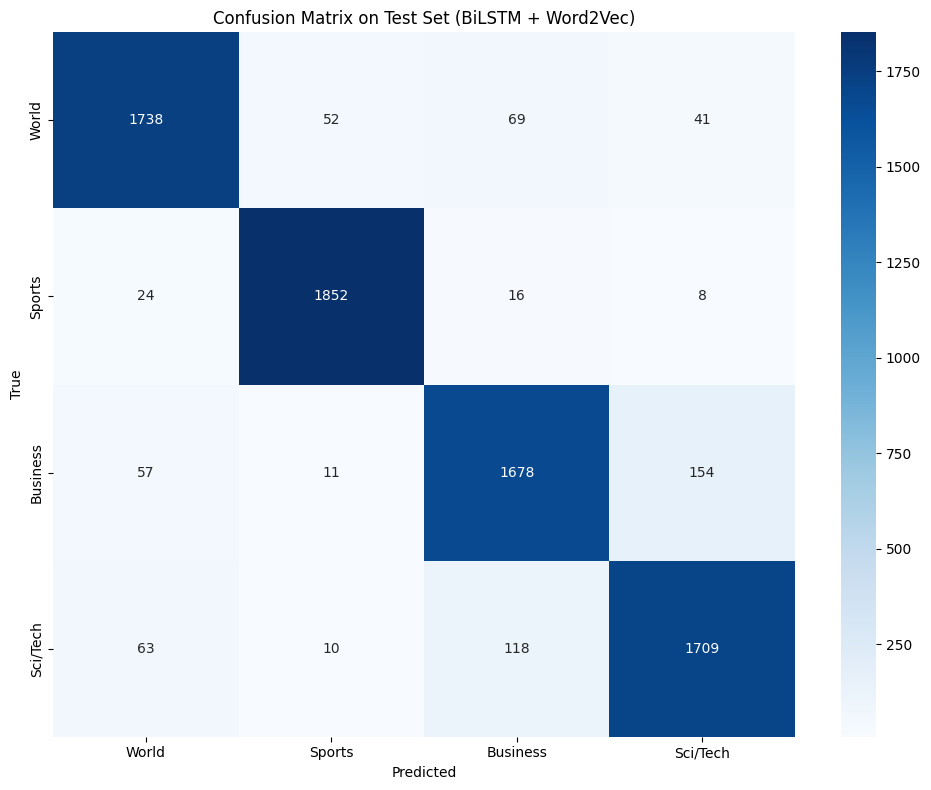

World: Precision=0.923, Recall=0.915, F1=0.919
Sports: Precision=0.962, Recall=0.975, F1=0.968
Business: Precision=0.892, Recall=0.883, F1=0.888
Sci/Tech: Precision=0.894, Recall=0.899, F1=0.897


In [79]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Test Set (BiLSTM + Word2Vec)')
plt.tight_layout()
plt.show()

for i, class_name in enumerate(class_names):
    precision = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() > 0 else 0
    recall = cm[i, i] / cm[i, :].sum() if cm[i, :].sum() > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"{class_name}: Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")


### Word2vec и Fasttext
Что пробовала:
1. Токенизацию   
Заменила Word2Vec на FastText — значимого улучшения не дало. На сайте (https://fasttext.cc/docs/en/supervised-models.html?from_column=20423&from=20423) есть модель предобученная для данного датасета и ее точность = 0.924 (т.е. здесь перспектив мало)
2. Максимальную длину последовательности    
Уменьшила max_len с 128 до 64.Поскольку 95% текстов короче 53 слов
3. Слой нормализации  
Добавила LayerNorm после эмбеддинга — стабильность обучения не изменилась
4. Pooling  
Заменила MaxPooling на AveragePooling — единственное изменение, которое внесло небольшой положительный вклад
5. Оптимизатор и scheduler  
Заменила Adam на AdamW + CosineAnnealingLR
Эффект неоднозначный, но ухудшения не было
6. Размер скрытого состояния  
Пробовала hidden_dim = 64, 128, 256  
hidden_dim = 128 показал себя наиболее стабильно  
Увеличение или уменьшение приводило к падению качества

8. Dropout
Подбирала dropout в диапазоне 0.3-0.5, но особо влияния не было